In [ ]:
# Hierarchical Clustering (HC)
"""
Hierarchical Clustering (HC) is an unsupervised machine learning algorithm used to group unlabeled data into clusters based on similarity. It is also known as Hierarchical Cluster Analysis (HCA).
In this algorithm, a hierarchy of clusters is created in the form of a tree. This tree-like structure is called a Dendrogram.

Dendrogram
A dendrogram is a tree-like diagram that records every merging or splitting step performed by the hierarchical clustering algorithm.
Y-axis: Represents the Euclidean distance (or dissimilarity) between clusters.
X-axis: Represents the individual data points.
Example Dendrogram (Alphabet Diagram)
Distance
  |
10|                     +-----------------------+
  |                     |                       |
  |               +-----+-----+                 |
  |               |           |                 |
 5|          +----+----+      |           +-----+-----+
  |          |         |      |           |           |
  |          A         B      C           D           E
  |
  +----------------------------------------------> Data Points
              A         B      C           D
"""

In [ ]:
# Hierarchical Clustering Techniques
"""
There are two approaches to Hierarchical Clustering.
1. Agglomerative Hierarchical Clustering (Bottom-Up Approach)
In the Agglomerative approach, each data point starts as an individual cluster. 
The algorithm repeatedly merges the two closest clusters until only one cluster remains.

Steps
1. Start with every data point as a separate cluster.
2. Find the two nearest clusters.
3. Merge them.
4. Repeat until all points belong to one cluster.

Example
Suppose we have four points:
A   B      C         D
Initially:
{A}   {B}   {C}   {D}
Step 1:
{A,B}   {C}   {D}
Step 2:
{A,B,C}   {D}
Step 3:
{A,B,C,D}
This is called the Bottom-Up approach because it starts from individual points and builds larger clusters.

2. Divisive Hierarchical Clustering (Top-Down Approach)
The Divisive approach is the reverse of Agglomerative Clustering. 
It starts with one large cluster containing all data points and repeatedly divides it into smaller clusters.

Steps
1.Start with one cluster containing all data points.
2. Split the cluster into two groups.
3. Continue splitting until each cluster contains only one point.

Example
Initially:
{A,B,C,D}
Step 1:
{A,B}      {C,D}
Step 2:
{A}   {B}     {C,D}
Step 3:
{A}   {B}     {C}   {D}
This is called the Top-Down approach because it begins with one large cluster and divides it into smaller clusters.
"""

In [ ]:
# Distance Measures (Linkage Methods)
"""
To decide which clusters should be merged, Hierarchical Clustering uses linkage methods. These methods calculate the distance between clusters.
1. Single Linkage (Nearest Neighbor)
The distance between two clusters is the minimum distance between any pair of points, one from each cluster.

Formula : Distance = Minimum distance between two clusters
Example
Cluster 1:
A   B
Cluster 2:
C   D
Distances:
A-C = 4
A-D = 8
B-C = 2
B-D = 6
Minimum distance:
min(4,8,2,6) = 2
So,
Single Linkage Distance = 2
Use: Forms long, chain-like clusters.

2. Complete Linkage (Farthest Neighbor)
The distance between two clusters is the maximum distance between any pair of points from different clusters.
Example
Distances:
A-C = 4
A-D = 8
B-C = 2
B-D = 6
Maximum distance:
max(4,8,2,6) = 8
Therefore,
Complete Linkage Distance = 8
Use: Produces compact and tightly grouped clusters.

3. Average Linkage
The distance between two clusters is the average of all pairwise distances between the points in the two clusters.
Example
Distances:
A-C = 4
A-D = 8
B-C = 2
B-D = 6
Average distance:
(4 + 8 + 2 + 6) / 4
= 20 / 4
= 5
Therefore,
Average Linkage Distance = 5
Use: Provides a balance between Single and Complete Linkage.

4. Threshold Linkage
In Threshold Linkage, clusters are merged only if the distance between them is less than or equal to a predefined threshold value.

Example
Suppose the threshold is:
Threshold = 5
Distances:
Cluster A-B = 3
Cluster C-D = 4
Cluster B-C = 7
Decision:
3 ≤ 5  → Merge ✔
4 ≤ 5  → Merge ✔
7 > 5  → Do Not Merge ✘
So, only clusters within the threshold distance are merged.

Use: Controls the maximum distance allowed for merging clusters.
"""

In [ ]:
# | Linkage Method        | Distance Used                      | Example Value | Cluster Shape             |
# | --------------------- | ---------------------------------- | ------------- | ------------------------- |
# | **Single Linkage**    | Minimum distance                   | 2             | Long, chain-like clusters |
# | **Complete Linkage**  | Maximum distance                   | 8             | Compact clusters          |
# | **Average Linkage**   | Average distance                   | 5             | Balanced clusters         |
# | **Threshold Linkage** | Merge only if distance ≤ threshold | Threshold = 5 | Controlled by threshold   |


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset=pd.read_csv("iris.raw.csv")
dataset.head(3)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2


In [3]:
dataset.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
dtype: int64

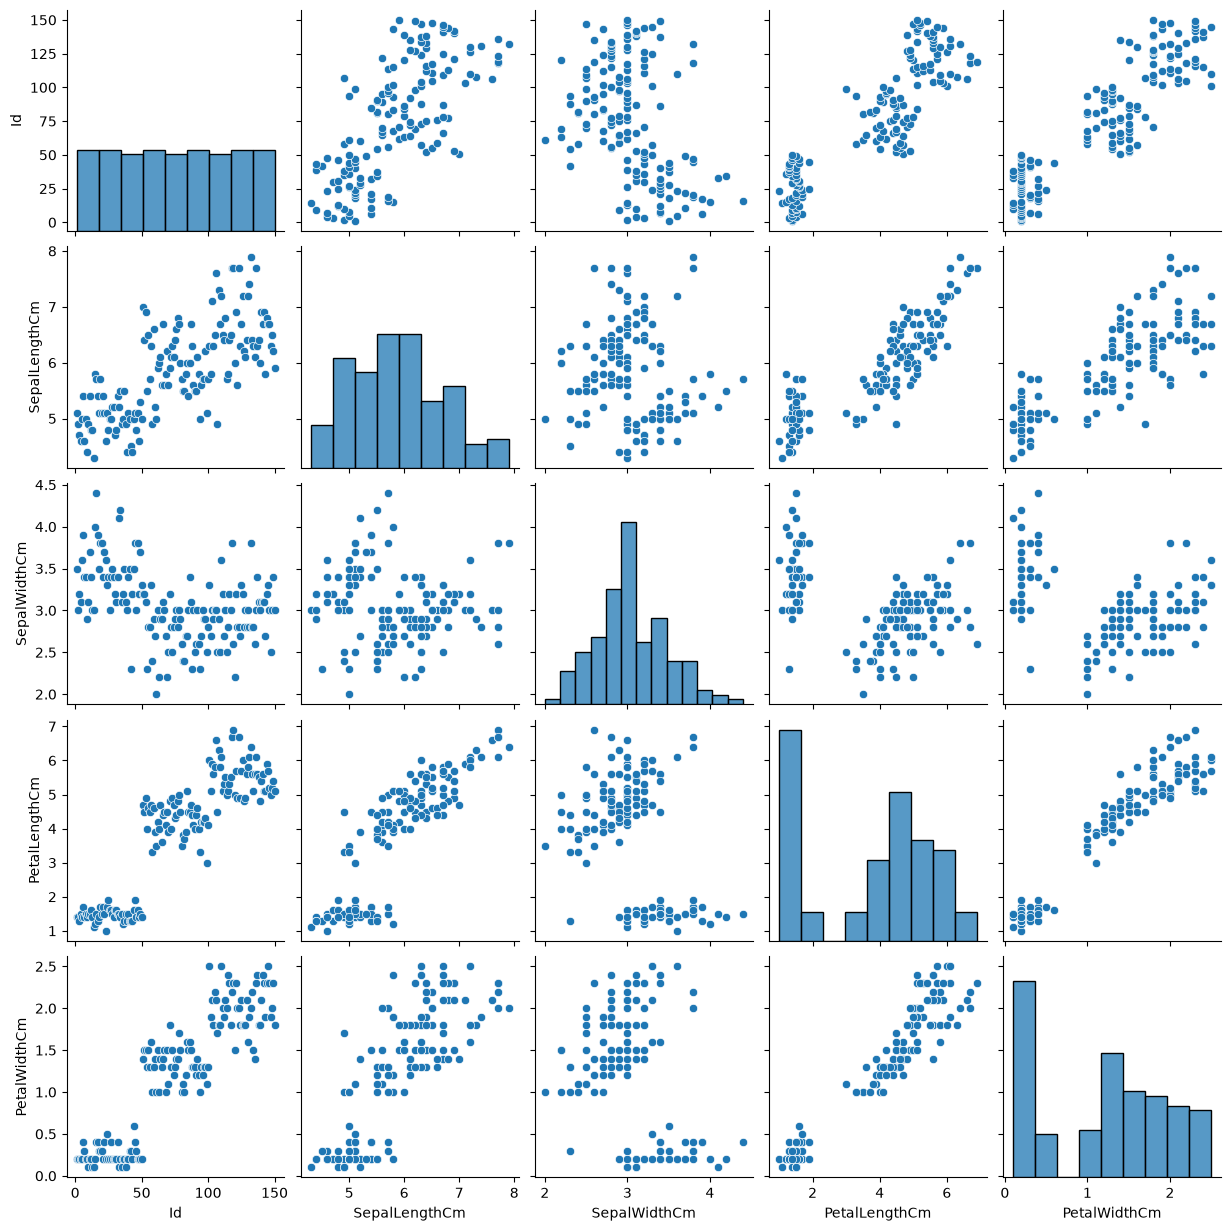

In [5]:
sns.pairplot(data=dataset)
plt.show()

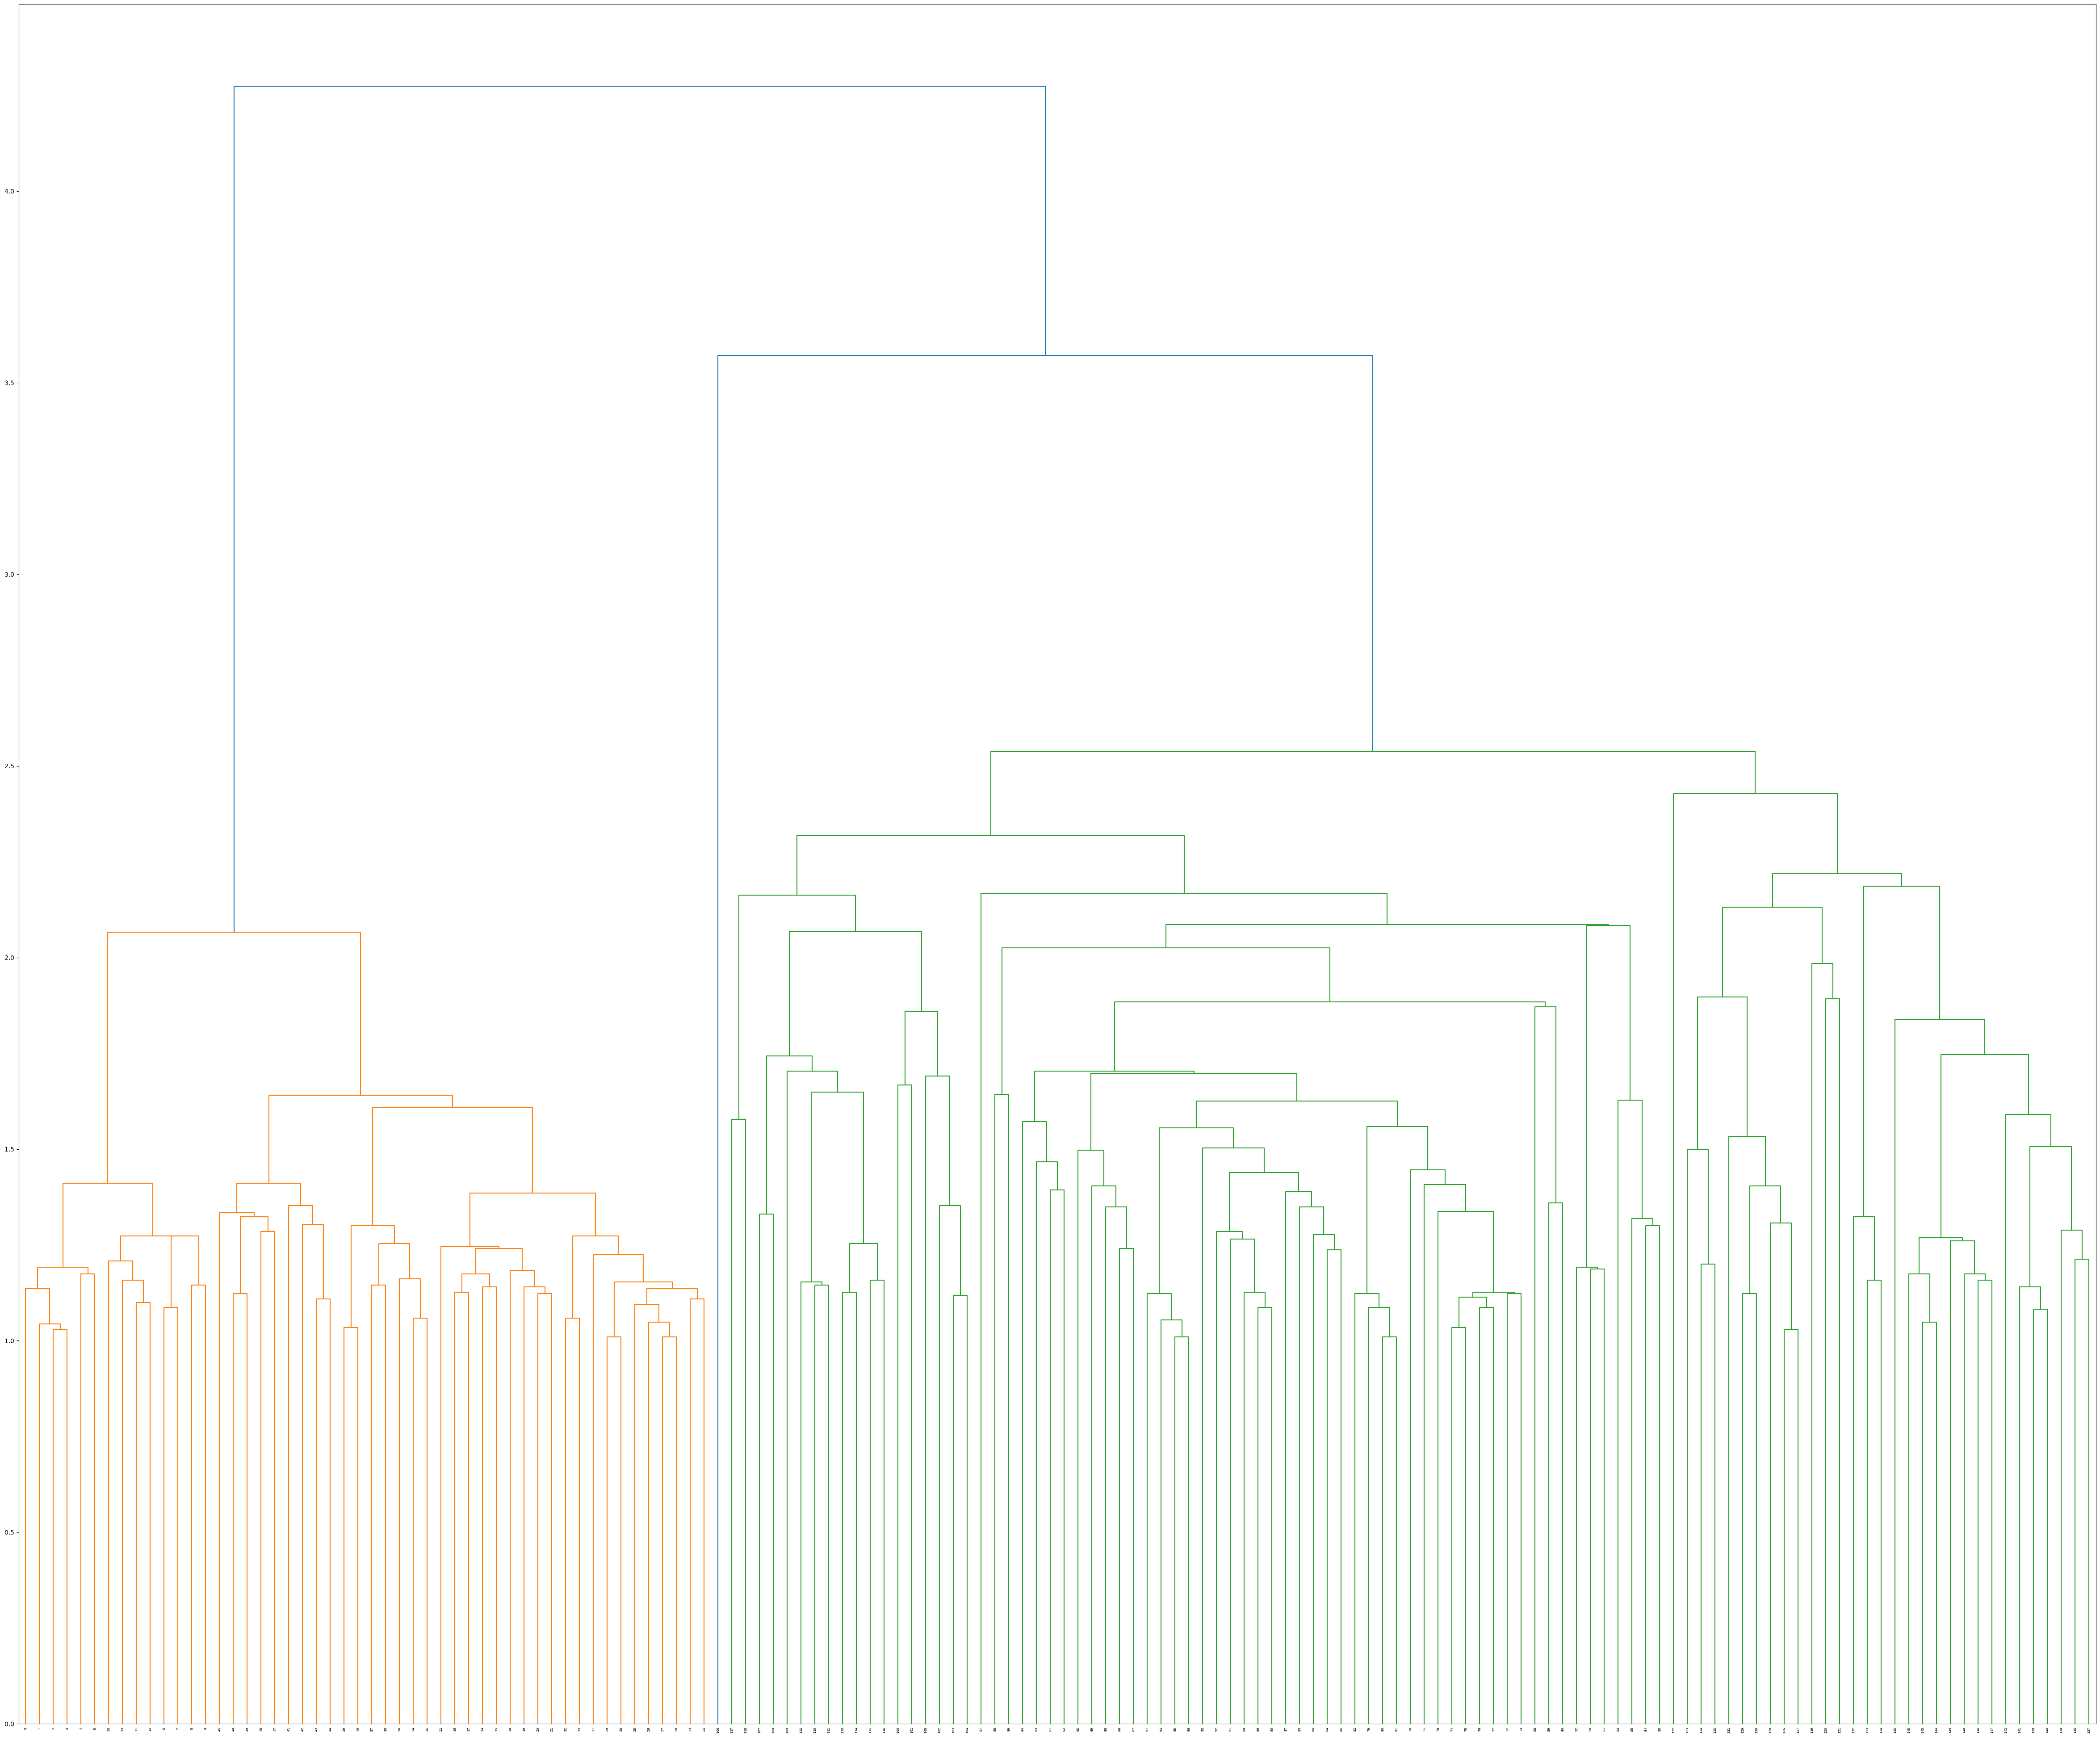

In [10]:
import scipy.cluster.hierarchy as sc
plt.figure(figsize=(60,50))
sc.dendrogram(sc.linkage(dataset , method='single',metric='euclidean'))
plt.savefig("Dendogram_AgglomerativeClustering")
plt.show()

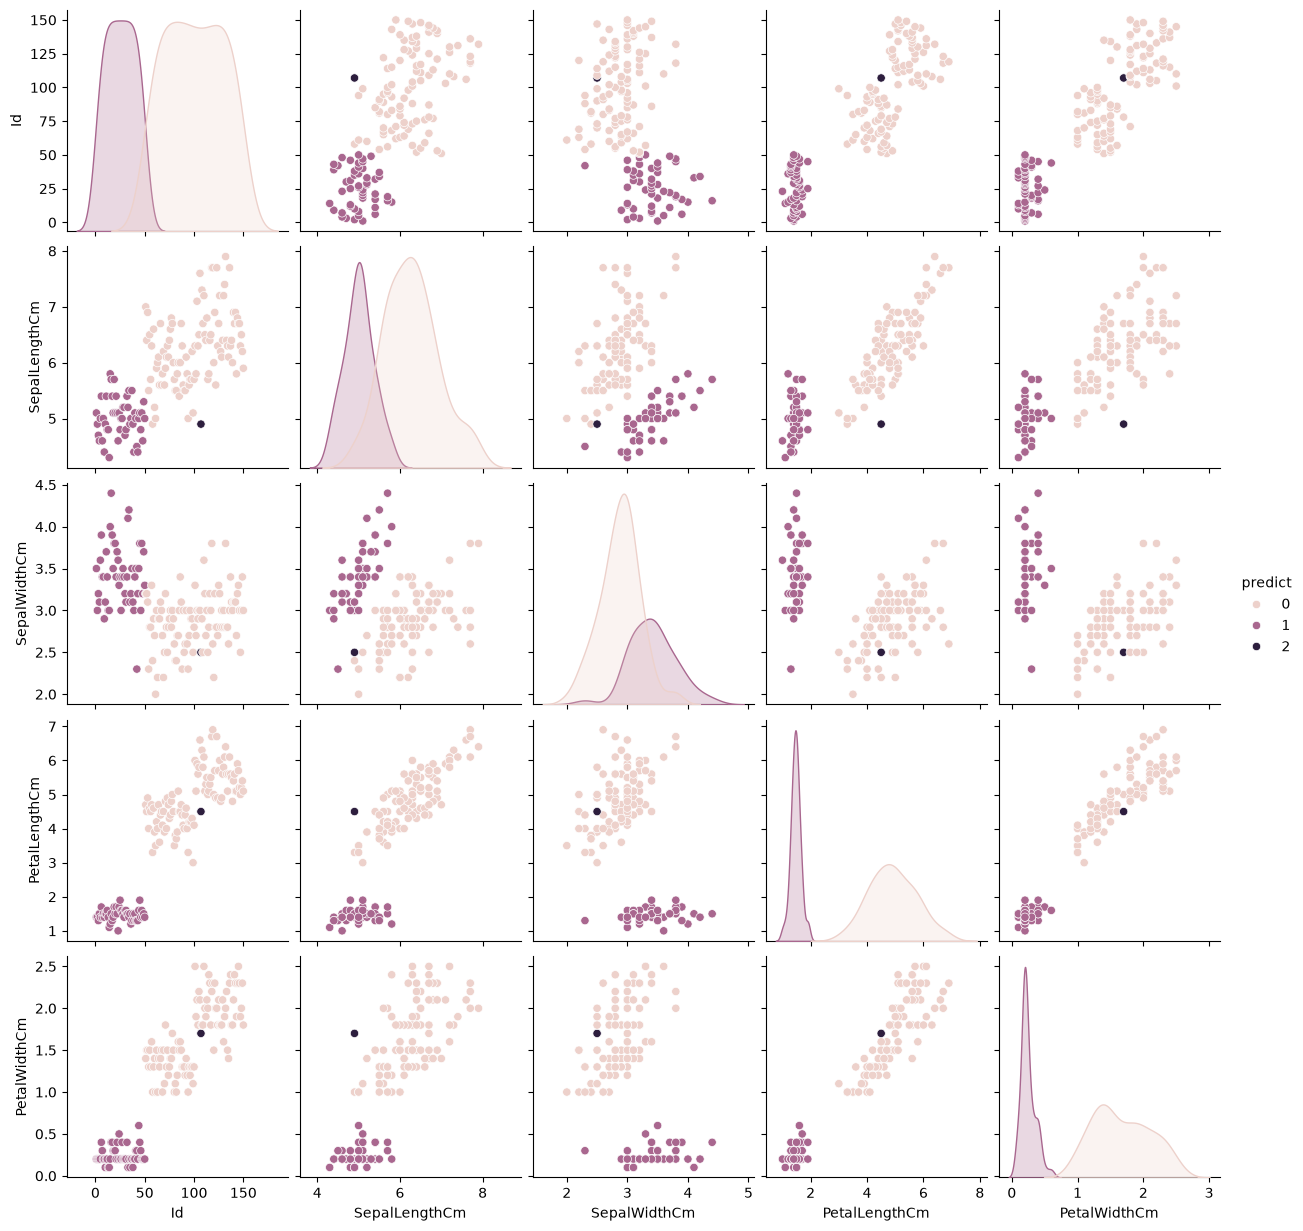

In [9]:
from sklearn.cluster import AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters=3,linkage='single')
dataset["predict"]=ac.fit_predict(dataset)
sns.pairplot(data=dataset,hue='predict')
plt.show()